┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 33.36 (χ²/ndof = 1.5)      │              Nfcn = 103              │
│ EDM = 9.09e-09 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

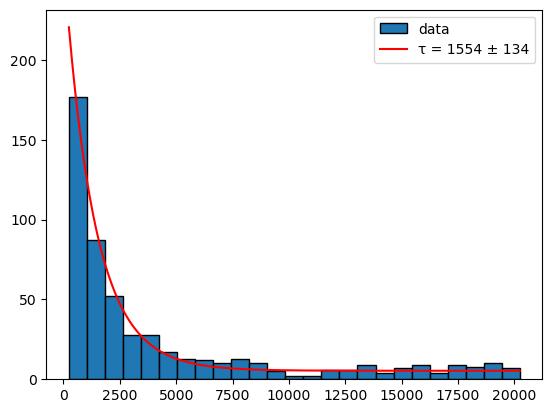

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares

lines = np.linspace(0, 100, 25000)

raw = '''
260
1680
2880
400
640
3760
720
6880
1120
1840
18640
320
4560
6720
10320
8880
7840
560
480
2320
7360
1360
400
400
3200
3280
1680
5520
400
18640
1760
13120
8000
3680
640
640
880
640
800
720
5040
18560
4560
5520
880
15600
12000
18720
4000
3680
1680
1760
4800
1600
14640
320
2160
640
1760
6320
8880
1680
480
240
1760
2720
2720
240
400
16880
720
800
15760
800
1920
880
880
12400
1520
1520
2640
4080
13360
720
1120
400
1840
1120
2000
18080
6560
5680
1680
15600
1200
3440
640
720
17360
2880
480
2640
1520
7280
15840
880
3920
560
1600
7120
2880
640
960
1120
1280
1520
1360
19120
3280
7520
1520
3040
7360
1280
9600
480
4400
240
960
5360
11600
6880
1040
15600
3840
14480
20000
12400
880
3040
16960
480
20160
2800
3040
960
19760
3520
18240
1600
1920
1360
320
560
1120
8720
8720
8800
4240
1440
320
1520
8160
1520
1120
1360
720
640
1680
17200
1360
320
2320
2400
3040
14240
640
960
2640
320
20160
480
240
560
960
800
8480
720
1360
560
800
480
4800
4720
640
400
1680
2160
3600
14080
3680
560
480
240
4240
3280
640
640
14000
3200
1120
4480
4560
19120
1200
17760
3440
8560
240
13360
3200
880
12080
240
400
1120
5280
18400
640
3360
400
560
2400
560
480
880
5200
2240
800
13120
240
1920
480
1280
5040
1520
10720
3600
3760
4000
5600
2400
3840
240
3680
1120
640
800
800
640
18080
5920
2480
2960
2560
18880
18560
9040
5840
1280
880
1600
560
8960
4000
2080
4800
9200
19120
480
2240
1040
1040
3440
1520
19200
7200
4720
18880
880
1680
880
10240
560
4160
1600
800
880
17920
11840
800
960
2400
1200
12640
19760
7520
1840
320
640
720
1200
240
1600
320
3760
880
400
1040
1760
4880
480
7360
19680
640
240
2880
2560
320
9360
12720
640
1680
560
11120
1520
5040
5120
1840
400
400
640
18480
1440
16560
240
7760
16160
960
5040
480
13200
3680
2480
400
1120
2400
8880
560
2720
880
1040
2560
13520
720
1760
8160
1040
2400
480
1040
6400
6480
1440
17120
560
3520
560
1520
1120
7200
4640
2080
20240
2560
15200
2000
400
1680
7440
18800
1440
13520
1680
2480
320
15040
2400
1920
1840
1840
1680
1040
9520
5520
1040
800
2880
480
13760
3200
15280
480
2960
400
240
2160
2480
6160
2160
2800
17520
880
16080
7920
640
960
7440
560
560
7840
15680
1120
480
800
480
6480
1920
14960
880
2320
4880
1600
1360
4080
960
1520
800
8560
1040
2400
5920
640
800
11440
640
1840
13760
6480
240
7920
720
2240
1520
4160
2640
4960
640
640
6240
560
880
1840
400
17120
480
4560
480
240
960
3440
1920
2320
12960
1200
3840
2240
1840
240
12480
1680
17360
560
560
640
17600
3600
240
240
400
640
6240
720
14880
16400
1440
480
320
1120
960
7840
240
800
2400
1920
2400
2400
720
1680
1680
1680
1760
560
400
17280
400
400
320
11920
16080
15040
720
880
2320
480
'''


data = np.array(raw.split(), dtype=int)

counts, bins = np.histogram(data, bins=25)
centers = (bins[:-1] + bins[1:]) / 2
errors = np.sqrt(np.maximum(counts, 1))   

def model(x, N, tau, C):
    return N* ( 2 * np.exp(-x / tau) + np.exp(-(1.5*x) / tau) ) + C

m = Minuit(LeastSquares(centers, counts, errors, model), N=200, tau=2000, C=5)
m.migrad()
m.hesse()
print(m)

plt.hist(data, bins=bins, edgecolor='black', label='data')
xs = np.linspace(bins[0], bins[-1], 300)
plt.plot(xs, model(xs, *m.values), 'r-', label=f"τ = {m.values['tau']:.0f} ± {m.errors['tau']:.0f}")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
import raw
from importlib import reload
reload(raw)
from raw import raw_data


lines = np.linspace(0, 100, 25000)

data = np.array(raw_data.split(), dtype=int)

counts, bins = np.histogram(data, bins=50)
centers = (bins[:-1] + bins[1:]) / 2
errors = np.sqrt(np.maximum(counts, 1))   

def model(x, N, tau, C):
    return N* ( 2 * np.exp(-x / tau) + np.exp(-(1.5*x) / tau) ) + C

m = Minuit(LeastSquares(centers, counts, errors, model), N=200, tau=2000, C=5)
m.migrad()
m.hesse()
print(m)

plt.hist(data, bins=bins, edgecolor='black', label='data')
xs = np.linspace(bins[0], bins[-1], 300)
plt.plot(xs, model(xs, *m.values), 'r-', label=f"τ = {m.values['tau']:.0f} ± {m.errors['tau']:.0f}")
plt.legend()
plt.show()

ValueError: invalid literal for int() with base 10: '3A'

[19840 13840 10720  5840  1120 16160  4400  3760  2000 19040]
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 65.53 (χ²/ndof = 1.4)      │              Nfcn = 226              │
│ EDM = 6.1e-05 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬──

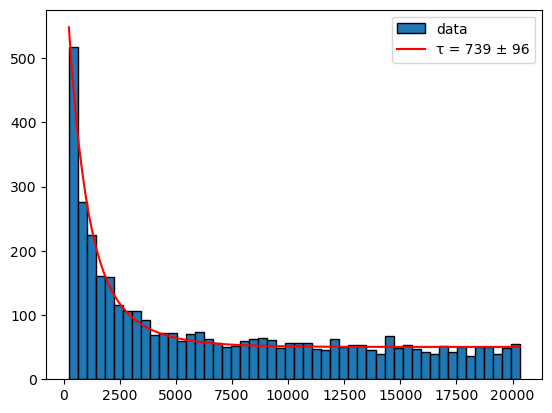

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
import raw
from importlib import reload
reload(raw)
from raw import raw_data


lines = np.linspace(0, 100, 25000)

data = np.array([int(h, 16)*80 for h in raw_data.split()])

print(data[0:10])

counts, bins = np.histogram(data, bins=50)
centers = (bins[:-1] + bins[1:]) / 2
errors = np.sqrt(np.maximum(counts, 1))   

def model(x, N, M, tau, C):
    return (N*np.exp(-x / tau) + M* (np.exp(-((1/2.5)*x) / tau) ) ) + C

m = Minuit(LeastSquares(centers, counts, errors, model), N=200, M = 200, tau=2000, C=5)
m.migrad()
m.hesse()
print(m)

plt.hist(data, bins=bins, edgecolor='black', label='data')
xs = np.linspace(bins[0], bins[-1], 300)
plt.plot(xs, model(xs, *m.values), 'r-', label=f"τ = {m.values['tau']:.0f} ± {m.errors['tau']:.0f}")
plt.legend()
plt.show()

[  560  5760  1120   560  1360  1600  6400   320   240 16720]
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 499.5 (χ²/ndof = 5.2)      │              Nfcn = 220              │
│ EDM = 0.000109 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬──

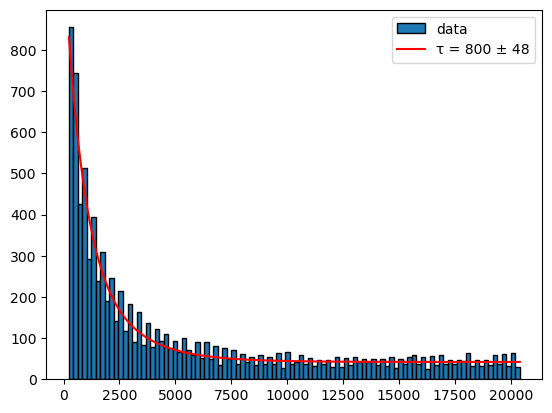

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
import raw
from importlib import reload
reload(raw)
from raw import raw_data_other


lines = np.linspace(0, 100, 25000)

data = np.array([int(h, 16)*80 for h in raw_data_other.split()])

print(data[0:10])

counts, bins = np.histogram(data, bins=100)
centers = (bins[:-1] + bins[1:]) / 2
errors = np.sqrt(np.maximum(counts, 1))   

def model(x, N, M, tau, C):
    return (N*np.exp(-x / tau) + M* (np.exp(-((1/2.5)*x) / tau) ) ) + C

m = Minuit(LeastSquares(centers, counts, errors, model), N=200, M = 200, tau=2000, C=5)
m.migrad()
m.hesse()
print(m)

plt.hist(data, bins=bins, edgecolor='black', label='data')
xs = np.linspace(bins[0], bins[-1], 300)
plt.plot(xs, model(xs, *m.values), 'r-', label=f"τ = {m.values['tau']:.0f} ± {m.errors['tau']:.0f}")
plt.legend()
plt.show()